In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv(r'C:\Users\sivap\OneDrive\Desktop\Intership\Iphone Sales Data set.csv')
df.head()


,iPhone_Model_Name,Date,Country,Region,Units_Sold,Revenue_USD,Average_Selling_Price,Market_Share_%,Growth_Rate_%,Google_Search_Index,...,Conversion_Rate_%,Storage_Variant,Color,Discount_%,Sales_Channel,Holiday_Season,Inflation_Rate,Preorders_Count,Return_Rate_%,Year
0,iPhone 17,22-06-2025,Brazil,South America,56090,67251910,1199,15.62,17.22,93,...,2.50,512GB,Gold,24.81,Retail Store,Yes,5.51,88305,3.10,2025
1,iPhone 17 Pro,23-09-2025,France,Europe,122059,121936941,999,31.90,10.08,86,...,4.35,1TB,Silver,18.89,Carrier,No,2.99,65623,3.40,2025
2,iPhone 17,03-11-2024,France,Europe,167906,167738094,999,24.73,-4.83,74,...,3.00,1TB,Titanium,5.70,Online,Yes,4.28,58016,2.22,2024
3,iPhone 17,09-05-2024,France,Europe,62254,80867946,1299,31.24,10.09,56,...,6.18,128GB,Black,13.88,Carrier,Yes,4.94,5049,4.99,2024
4,iPhone 17,26-01-2025,Canada,North America,127893,140554407,1099,41.92,15.41,58,...,5.65,256GB,Blue,21.17,Retail Store,No,7.07,62040,3.57,2025


In [11]:
df.shape

(505, 22)

In [12]:
df.columns

Index(['iPhone_Model_Name', 'Date', 'Country', 'Region', 'Units_Sold',
       'Revenue_USD', 'Average_Selling_Price', 'Market_Share_%',
       'Growth_Rate_%', 'Google_Search_Index', 'Social_Media_Mentions',
       'Ad_Spend_USD', 'Conversion_Rate_%', 'Storage_Variant', 'Color',
       'Discount_%', 'Sales_Channel', 'Holiday_Season', 'Inflation_Rate',
       'Preorders_Count', 'Return_Rate_%', 'Year'],
      dtype='str')

In [13]:
df.isnull().sum()

iPhone_Model_Name        0
Date                     0
Country                  0
Region                   0
Units_Sold               0
Revenue_USD              0
Average_Selling_Price    0
Market_Share_%           0
Growth_Rate_%            0
Google_Search_Index      0
Social_Media_Mentions    0
Ad_Spend_USD             0
Conversion_Rate_%        0
Storage_Variant          0
Color                    0
Discount_%               0
Sales_Channel            0
Holiday_Season           0
Inflation_Rate           0
Preorders_Count          0
Return_Rate_%            0
Year                     0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
# finding regional sales
regional_sales = df.groupby('Region')['Units_Sold'].sum()
print(regional_sales)

Region
Asia             10982593
Europe           13907824
Middle East       4448410
North America     8202388
Oceania           5574743
South America     4118556
Name: Units_Sold, dtype: int64


In [16]:
# finding highest sales region
highest_sales_region = df.groupby('Region')['Units_Sold'].sum().idxmax()
print(highest_sales_region)

Europe


In [17]:
# finding indian sales
indian_sales = df[df['Country'] == 'India']['Units_Sold'].sum()
print(indian_sales)

6355733


In [18]:
# finding highest sales country
highest_sales_country = df.groupby('Country')['Units_Sold'].sum().idxmax()  
print(highest_sales_country)

India


In [19]:
# finding google search index in india
google_search_index_india = df[df['Country'] == 'India']['Google_Search_Index'].mean()
print(google_search_index_india)

71.24590163934427


In [20]:
# finding google search index in all countries
google_search_index_all = df.groupby('Country')['Google_Search_Index'].mean()   
print(google_search_index_all)

Country
Australia    74.313725
Brazil       78.146341
Canada       72.784314
France       76.157895
Germany      73.980000
India        71.245902
Japan        76.215686
UAE          77.437500
UK           77.018519
USA          73.243902
Name: Google_Search_Index, dtype: float64


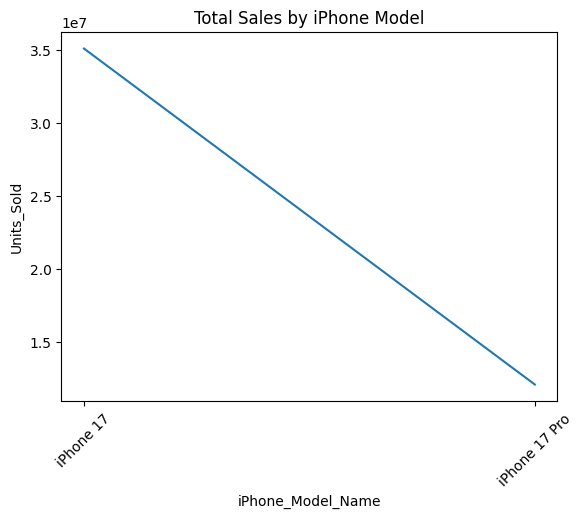

In [21]:
model_sales = df.groupby("iPhone_Model_Name")["Units_Sold"].sum().reset_index()

plt.figure()
sns.lineplot(data=model_sales, x="iPhone_Model_Name", y="Units_Sold")
plt.title("Total Sales by iPhone Model")
plt.xticks(rotation=45)
plt.show()

In [22]:
df.columns

Index(['iPhone_Model_Name', 'Date', 'Country', 'Region', 'Units_Sold',
       'Revenue_USD', 'Average_Selling_Price', 'Market_Share_%',
       'Growth_Rate_%', 'Google_Search_Index', 'Social_Media_Mentions',
       'Ad_Spend_USD', 'Conversion_Rate_%', 'Storage_Variant', 'Color',
       'Discount_%', 'Sales_Channel', 'Holiday_Season', 'Inflation_Rate',
       'Preorders_Count', 'Return_Rate_%', 'Year'],
      dtype='str')

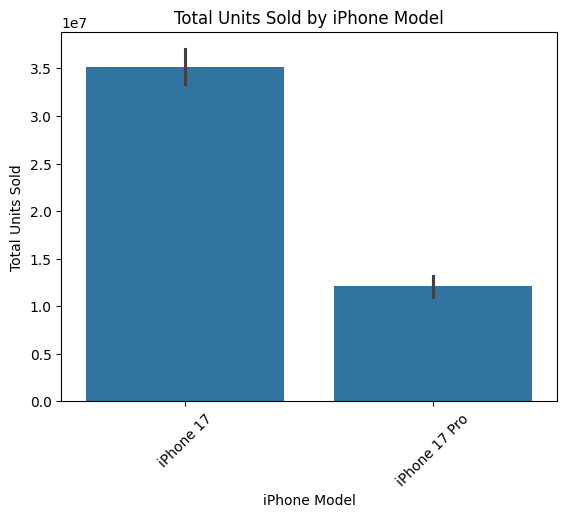

In [ ]:
# Finding total units sold by model
plt.figure()
sns.barplot(data=df, x='iPhone_Model_Name', y='Units_Sold', estimator=sum)
plt.xticks(rotation=45)
plt.title("Total Units Sold by iPhone Model")
plt.xlabel("iPhone Model")
plt.ylabel("Total Units Sold")
plt.show()

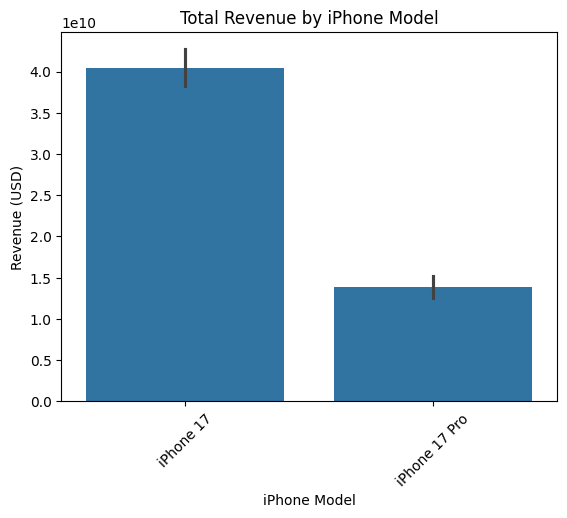

In [ ]:
# Finding total revenue by model
plt.figure()
sns.barplot(data=df, x='iPhone_Model_Name', y='Revenue_USD', estimator=sum)
plt.xticks(rotation=45)
plt.title("Total Revenue by iPhone Model")
plt.xlabel("iPhone Model")
plt.ylabel("Revenue (USD)")
plt.show()

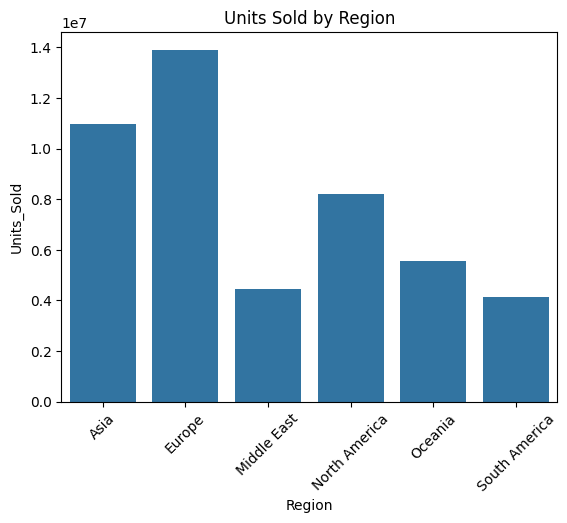

In [ ]:
# Finding Total units sold by region
region_sales = df.groupby('Region')['Units_Sold'].sum().reset_index()

plt.figure()
sns.barplot(data=region_sales, x='Region', y='Units_Sold')
plt.title("Units Sold by Region")
plt.xticks(rotation=45)
plt.show()


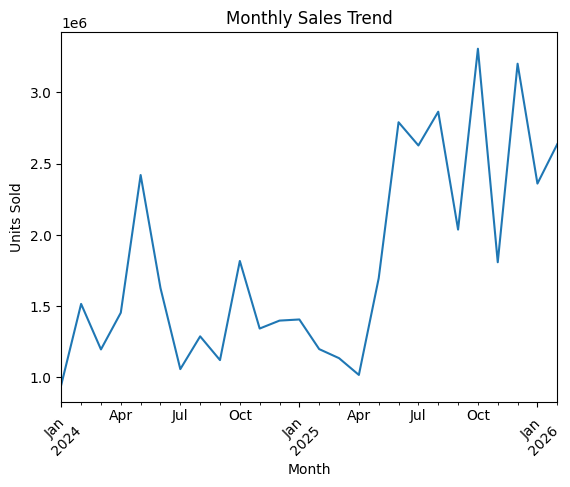

In [ ]:
# Monthly sales trend
monthly_sales = df.groupby(df['Date'].dt.to_period("M"))['Units_Sold'].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

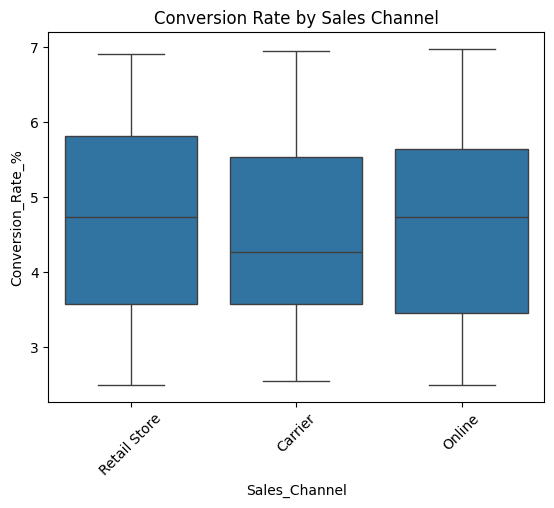

In [ ]:
# Total conversion rate by sales channel 
plt.figure()
sns.boxplot(data=df, x='Sales_Channel', y='Conversion_Rate_%')
plt.xticks(rotation=45)
plt.title("Conversion Rate by Sales Channel")
plt.show()

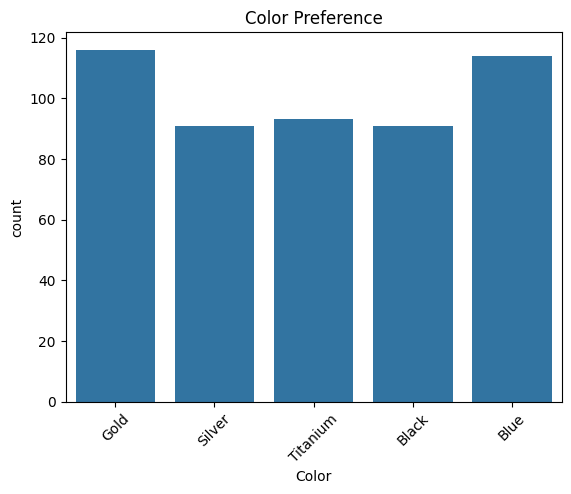

In [ ]:
# Finding Most sales by colors
plt.figure()
sns.countplot(data=df, x='Color')
plt.xticks(rotation=45)
plt.title("Color Preference")
plt.show()